Mapping nhãn: {'no': np.int64(0), 'yes': np.int64(1)}

BẮT ĐẦU CROSS-VALIDATION (5 FOLDS) VỚI THRESHOLD = 0.6

--- Đang chạy model: Logistic Regression ---
   -> Average F1: 0.5157 | Recall: 0.7730
--- Đang chạy model: SVM ---
   -> Average F1: 0.0185 | Recall: 0.0095
--- Đang chạy model: Random Forest ---
   -> Average F1: 0.0202 | Recall: 0.0104
--- Đang chạy model: XGBoost ---
   -> Average F1: 0.3757 | Recall: 0.3495
--- Đang chạy model: LightGBM ---


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-package

   -> Average F1: 0.4182 | Recall: 0.4282

===== BẢNG TỔNG KẾT (TRUNG BÌNH 5 FOLDS) =====
                 Model  Accuracy  Precision (Yes)  Recall (Yes)  F1-Score
0  Logistic Regression  0.607692         0.387531      0.773008  0.515717
4             LightGBM  0.679744         0.410048      0.428233  0.418153
3              XGBoost  0.688718         0.409276      0.349461  0.375696
2        Random Forest  0.728718         0.374444      0.010445  0.020245
1                  SVM  0.728462         0.366667      0.009506  0.018485


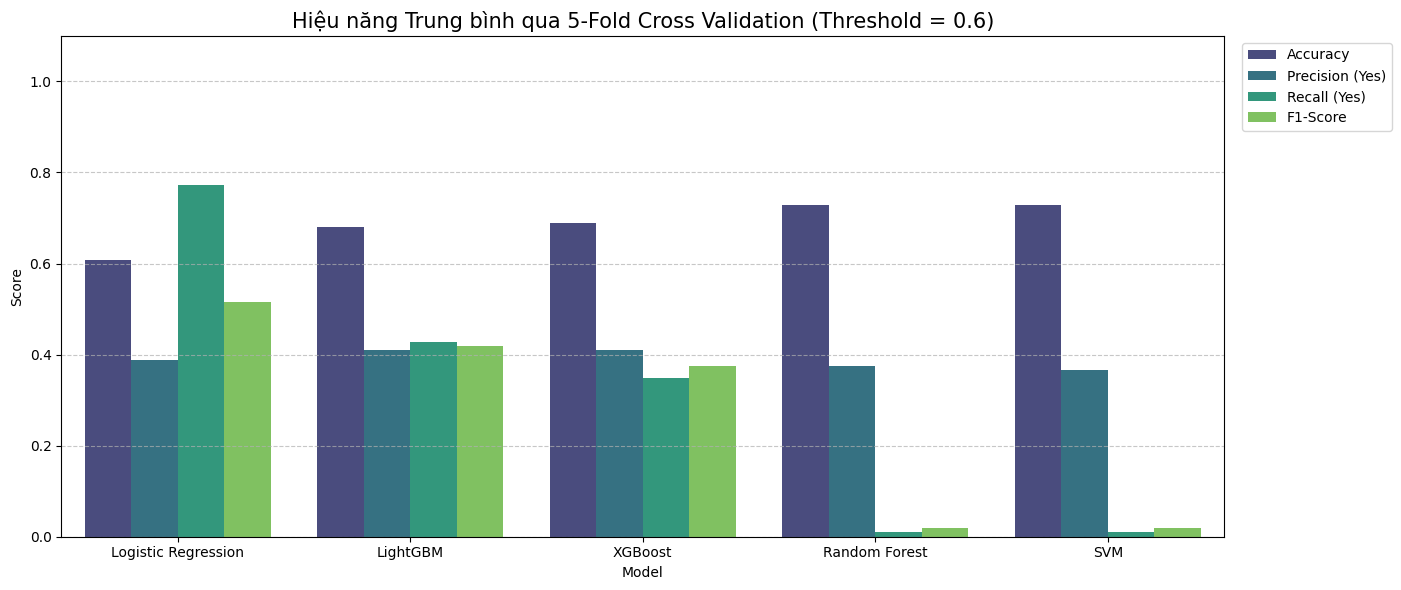

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- 1. Chuẩn bị dữ liệu ---
df = pd.read_csv('backend/shopping_behavior_updated.csv')

TARGET_COL = "Subscription Status"
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()

# Mã hóa Label: yes -> 1, no -> 0
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])
print(f"Mapping nhãn: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Bỏ cột không cần thiết
drop_cols = [
    "Customer ID", "Item Purchased", "Location", "Color", "Size", 
    "Promo Code Used", "Discount Applied", 
    TARGET_COL
]
X = df.drop(columns=drop_cols)

# --- 2. Preprocessing ---
numeric_features = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Tính toán scale_pos_weight chung cho toàn bộ tập dữ liệu (ước lượng)
# Để chính xác tuyệt đối thì nên tính trong từng fold, nhưng tính gộp ở đây cũng chấp nhận được
scale_pos_weight_val = (len(y) - sum(y)) / sum(y)

# --- 3. Cấu hình các model ---
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "SVM": SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', 
        scale_pos_weight=scale_pos_weight_val, 
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced', verbosity=-1, random_state=42
    )
}

# --- 4. Thực hiện Cross-Validation với Threshold tùy chỉnh ---
THRESHOLD = 0.6
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

results_data = []

print(f"\n{'='*60}")
print(f"BẮT ĐẦU CROSS-VALIDATION ({N_SPLITS} FOLDS) VỚI THRESHOLD = {THRESHOLD}")
print(f"{'='*60}\n")

for name, model in models.items():
    print(f"--- Đang chạy model: {name} ---")
    
    # Lưu điểm số của từng fold
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    
    # Tạo pipeline
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    
    # Vòng lặp K-Fold
    for fold_idx, (train_index, val_index) in enumerate(skf.split(X, y)):
        # Chia dữ liệu theo index của fold hiện tại
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y[train_index], y[val_index]
        
        # Huấn luyện
        clf.fit(X_train_fold, y_train_fold)
        
        # Dự đoán xác suất
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(X_val_fold)[:, 1]
        else:
            y_proba = clf.decision_function(X_val_fold)
            y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

        # Áp dụng ngưỡng 0.6
        y_pred_threshold = (y_proba >= THRESHOLD).astype(int)
        
        # Tính metrics cho fold này
        fold_accuracies.append(accuracy_score(y_val_fold, y_pred_threshold))
        fold_precisions.append(precision_score(y_val_fold, y_pred_threshold, pos_label=1, zero_division=0))
        fold_recalls.append(recall_score(y_val_fold, y_pred_threshold, pos_label=1))
        fold_f1s.append(f1_score(y_val_fold, y_pred_threshold, pos_label=1))
    
    # Tính trung bình các folds
    avg_acc = np.mean(fold_accuracies)
    avg_prec = np.mean(fold_precisions)
    avg_rec = np.mean(fold_recalls)
    avg_f1 = np.mean(fold_f1s)
    
    print(f"   -> Average F1: {avg_f1:.4f} | Recall: {avg_rec:.4f}")

    results_data.append({
        "Model": name,
        "Accuracy": avg_acc,
        "Precision (Yes)": avg_prec,
        "Recall (Yes)": avg_rec,
        "F1-Score": avg_f1
    })

# --- 5. Tổng hợp và Trực quan hóa ---
results_df = pd.DataFrame(results_data).sort_values(by="F1-Score", ascending=False)

print("\n===== BẢNG TỔNG KẾT (TRUNG BÌNH 5 FOLDS) =====")
print(results_df)

plt.figure(figsize=(14, 6))
melted_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title(f"Hiệu năng Trung bình qua 5-Fold Cross Validation (Threshold = {THRESHOLD})", fontsize=15)
plt.ylim(0, 1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()